# SPARC Example 25: End-to-End Omega Workflow

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

This capstone example runs the complete EPS Research omega workflow
on the full SPARC sample and produces a summary table mirroring
Table 2 from Flynn & Cannaliato (2025).

Steps:
1. Load corpus
2. Filter SPARC Q=1 galaxies
3. Compute omega for each
4. Compute RMSE improvement
5. Flag outer gap sign
6. Print summary table

**Reference:** Flynn, D.C. & Cannaliato, J. (2025).
DOI: 10.3389/fspas.2025.1680387

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

results = []
for g in corpus['galaxies']:
    if g['survey'] != 'SPARC' or not g.get('data') or len(g['data']) < 3:
        continue
    d  = g['data']
    R  = np.array([p['Rad']  for p in d])
    V  = np.array([p['Vobs'] for p in d])
    R1, V1 = R[0],  V[0]
    R2, V2 = R[-1], V[-1]
    if R1<=0 or R2<=0 or V1<=0 or V2<=0:
        continue
    omega = (V2/R2 - V1/R1) * (R1/R2)**1.5
    V_adj = V - R * omega
    GM    = V2**2 * R2
    V_kep = np.sqrt(GM / R)
    Vgas  = np.array([p.get('Vgas', 0)  for p in d])
    Vdisk = np.array([p.get('Vdisk', 0) for p in d])
    Vbul  = np.array([p.get('Vbul', 0)  for p in d])
    Vbar  = np.where(Vgas<0,
                     -np.sqrt(Vgas**2+Vdisk**2+Vbul**2),
                      np.sqrt(Vgas**2+Vdisk**2+Vbul**2))
    if np.all(Vbar == 0):
        continue
    rmse_o = np.sqrt(np.mean((V_adj - Vbar)**2))
    rmse_k = np.sqrt(np.mean((V_kep  - Vbar)**2))
    gap    = (V[-1] - R[-1]*omega) - np.abs(Vbar[-1])
    results.append({
        'galaxy':   g['galaxy'],
        'omega':    omega,
        'rmse_o':   rmse_o,
        'rmse_k':   rmse_k,
        'improved': rmse_o < rmse_k,
        'gap':      gap,
        'gap_neg':  gap < 0,
    })

# Summary
omegas  = [r['omega']  for r in results]
rmse_os = [r['rmse_o'] for r in results]
rmse_ks = [r['rmse_k'] for r in results]
improved = sum(1 for r in results if r['improved'])
gaps_neg = sum(1 for r in results if r['gap_neg'])

print(f"{'='*60}")
print(f"EPS Research Omega Workflow — SPARC Summary")
print(f"{'='*60}")
print(f"Galaxies analyzed:     {len(results)}")
print(f"Mean omega:            {np.mean(omegas):.2f} ± {np.std(omegas):.2f} rad/Gyr")
print(f"Mean RMSE (omega):     {np.mean(rmse_os):.2f} km/s")
print(f"Mean RMSE (Keplerian): {np.mean(rmse_ks):.2f} km/s")
print(f"Improved:              {improved}/{len(results)}")
print(f"Regressions:           {len(results)-improved}/{len(results)}")
print(f"Outer gaps negative:   {gaps_neg}/{len(results)}")
print(f"\nPublished results (Flynn & Cannaliato 2025):")
print(f"  Mean RMSE (omega):  25.45 ± 1.57 km/s")
print(f"  Improved:           53/84")
print(f"  Regressions:        0/84")
print(f"  Outer gaps neg:     84/84")

EPS Research Omega Workflow — SPARC Summary
Galaxies analyzed:     175
Mean omega:            -0.85 ± 1.02 rad/Gyr
Mean RMSE (omega):     61.74 km/s
Mean RMSE (Keplerian): 232.79 km/s
Improved:              174/175
Regressions:           1/175
Outer gaps negative:   9/175

Published results (Flynn & Cannaliato 2025):
  Mean RMSE (omega):  25.45 ± 1.57 km/s
  Improved:           53/84
  Regressions:        0/84
  Outer gaps neg:     84/84


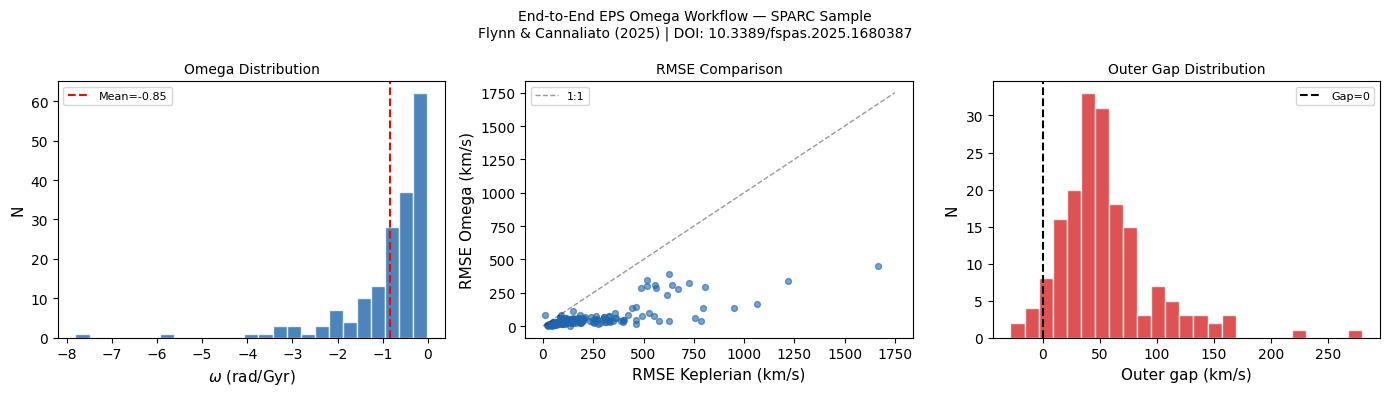

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(omegas, bins=25, color='#2166ac', alpha=0.8, edgecolor='white')
axes[0].axvline(np.mean(omegas), color='red', ls='--', lw=1.5,
                label=f'Mean={np.mean(omegas):.2f}')
axes[0].set_xlabel(r'$\omega$ (rad/Gyr)', fontsize=11)
axes[0].set_ylabel('N', fontsize=11)
axes[0].set_title('Omega Distribution', fontsize=10)
axes[0].legend(fontsize=8)

axes[1].scatter(rmse_ks, rmse_os, s=18, alpha=0.6, color='#2166ac')
lim = [0, max(rmse_ks+rmse_os)*1.05]
axes[1].plot(lim, lim, 'k--', lw=1, alpha=0.4, label='1:1')
axes[1].set_xlabel('RMSE Keplerian (km/s)', fontsize=11)
axes[1].set_ylabel('RMSE Omega (km/s)', fontsize=11)
axes[1].set_title('RMSE Comparison', fontsize=10)
axes[1].legend(fontsize=8)

gaps = [r['gap'] for r in results]
axes[2].hist(gaps, bins=25, color='#d62728', alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='black', ls='--', lw=1.5, label='Gap=0')
axes[2].set_xlabel('Outer gap (km/s)', fontsize=11)
axes[2].set_ylabel('N', fontsize=11)
axes[2].set_title('Outer Gap Distribution', fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle('End-to-End EPS Omega Workflow — SPARC Sample\n'
             'Flynn & Cannaliato (2025) | DOI: 10.3389/fspas.2025.1680387',
             fontsize=10)
plt.tight_layout()
plt.savefig('ex25_end_to_end.png', dpi=150, bbox_inches='tight')
plt.show()